# 📥 STEP 1 — Install Dependencies
Install all required libraries before running any other cell.

In [ ]:
# Install PDF parsing, NLP, and ML libraries
!pip install PyPDF2 pdfminer.six #to extract text,metadata and pages from pdf files
!pip install textblob scipy gensim networkx nltk
#textblob-simple nlp tasks(sentimental analysis)
#scipy-scientific computing(math,statistics)
#gensim-topic modeling and word embeddings
!pip install scikit-learn spacy
!python -m spacy download en_core_web_sm
!python -m nltk.downloader all

# 📥 STEP 2 — Download Papers from Conferences
Run each scraper block below to download papers from NeurIPS, CVPR, EMNLP, ACL, and non-publishable arXiv papers.

> ⚠️ **Note:** ICCV 2025 and EMNLP 2025 may not be live yet. If downloads fail, use ICCV2023 / 2024.emnlp-main as fallbacks.

In [ ]:
# ─────────────────────────────────────────────
# DOWNLOAD: NeurIPS 2023 papers
# Source: https://papers.nips.cc
# Saves to: /content/neurips_papers/
# ─────────────────────────────────────────────
import requests #http library for making web requests
from bs4 import BeautifulSoup #html/xml parser for extracting data from web pages
import os #built in module for file and folder operations
import time #built in module for adding delays between requests
#base url and target year
BASE = "https://papers.nips.cc"
YEAR = "2023"
#full url for the NeurIPS paper index
url = f"{BASE}/paper/{YEAR}"
headers = {"User-Agent": "Mozilla/5.0"}
#output folder
os.makedirs("/content/neurips_papers", exist_ok=True)

# Get list of paper abstract links from the NeurIPS index page
res = requests.get(url, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")
# collect all links that point to individual paper abstract pages
paper_links = []
for a in soup.find_all("a"):
    href = a.get("href")
    if href and "hash" in href and "Abstract" in href:
        paper_links.append(BASE + href)

print("Found papers:", len(paper_links))

count = 0
# Visit each abstract paper page and download its PDF
for link in paper_links:
    try:
        #fetch the individual paper page
        page = requests.get(link, headers=headers)
        page_soup = BeautifulSoup(page.text, "html.parser")
        #find the pdf download link on the page
        for a in page_soup.find_all("a"):
            href = a.get("href")
            if href and href.endswith(".pdf"):
                pdf_url = BASE + href
                file_name = f"/content/neurips_papers/paper_{count+1}.pdf"
                #download and save the pdf
                print(f"Downloading {count+1}: {pdf_url}")
                pdf = requests.get(pdf_url, headers=headers)
                with open(file_name, "wb") as f:
                    f.write(pdf.content)
                count += 1
                time.sleep(1)  #pause to avoid overloading the server
                break #move to the next paper after first pdf found

        if count >= 100:  #stop after downloading 100 papers
            break
    except Exception as e:
        print("Error:", e)

print("NeurIPS Downloaded:", count)

In [ ]:
# ─────────────────────────────────────────────
# DOWNLOAD: CVPR 2024 papers
# Source: https://openaccess.thecvf.com
# Saves to: /content/cvpr_papers/
# ─────────────────────────────────────────────
BASE = "https://openaccess.thecvf.com"
URL = "https://openaccess.thecvf.com/CVPR2024?day=all"
headers = {"User-Agent": "Mozilla/5.0"}

save_path = "/content/cvpr_papers"
os.makedirs(save_path, exist_ok=True)

res = requests.get(URL, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

# Collect individual paper page links
paper_pages = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if "html" in href and "CVPR2024" in href:
        paper_pages.append(BASE + "/" + href)

paper_pages = list(set(paper_pages))
print("Paper pages found:", len(paper_pages))

count = 0
# Visit each paper page and extract the PDF download link
for link in paper_pages:
    try:
        page = requests.get(link, headers=headers)
        page_soup = BeautifulSoup(page.text, "html.parser")

        for a in page_soup.find_all("a", href=True):
            href = a["href"]
            if "paper.pdf" in href:
                pdf_url = BASE + "/" + href
                file_name = os.path.join(save_path, f"paper_{count+1}.pdf")
                print(f"Downloading {count+1}")
                pdf = requests.get(pdf_url, headers=headers)
                with open(file_name, "wb") as f:
                    f.write(pdf.content)
                count += 1
                time.sleep(1)
                break

        if count >= 100:
            break
    except Exception as e:
        print("Error:", e)

print("CVPR Downloaded:", count)

In [ ]:
# ─────────────────────────────────────────────
# DOWNLOAD: EMNLP 2024 papers
# Source: https://aclanthology.org
# Saves to: /content/emnlp2024_papers/
# ⚠️  Changed from 2025 → 2024 (2025 not yet published)
# ─────────────────────────────────────────────
BASE = "https://aclanthology.org"
URL = "https://aclanthology.org/2024.emnlp-main/"   # ← safe fallback
headers = {"User-Agent": "Mozilla/5.0"}

save_path = "/content/emnlp2024_papers"
os.makedirs(save_path, exist_ok=True)

res = requests.get(URL, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

pdf_links = []
# Grab all direct .pdf links from the anthology page
for a in soup.find_all("a", href=True):
    href = a["href"]
    if href.endswith(".pdf"):
        pdf_links.append(href if href.startswith("http") else BASE + href)

print("Total PDFs found:", len(pdf_links))

count = 0
for link in pdf_links:
    try:
        file_name = os.path.join(save_path, f"paper_{count+1}.pdf")
        print(f"Downloading {count+1}")
        pdf = requests.get(link, headers=headers)
        with open(file_name, "wb") as f:
            f.write(pdf.content)
        count += 1
        time.sleep(1)
        if count >= 100:
            break
    except Exception as e:
        print("Error:", e)

print("EMNLP Downloaded:", count)

In [ ]:
# ─────────────────────────────────────────────
# DOWNLOAD: ACL 2024 papers
# Source: https://aclanthology.org
# Saves to: /content/acl2024_papers/
# ⚠️  Changed from 2025 → 2024 (2025 not yet published)
# ─────────────────────────────────────────────
BASE = "https://aclanthology.org"
URL = "https://aclanthology.org/2024.acl-long/"   # ← safe fallback
headers = {"User-Agent": "Mozilla/5.0"}

save_path = "/content/acl2024_papers"
os.makedirs(save_path, exist_ok=True)

res = requests.get(URL, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

pdf_links = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if href.endswith(".pdf"):
        pdf_links.append(href if href.startswith("http") else BASE + href)

print("Total PDFs found:", len(pdf_links))

count = 0
for link in pdf_links:
    try:
        file_name = os.path.join(save_path, f"paper_{count+1}.pdf")
        print(f"Downloading {count+1}")
        pdf = requests.get(link, headers=headers)
        with open(file_name, "wb") as f:
            f.write(pdf.content)
        count += 1
        time.sleep(1)
        if count >= 100:
            break
    except Exception as e:
        print("Error:", e)

print("ACL Downloaded:", count)

In [ ]:
# ─────────────────────────────────────────────
# DOWNLOAD: ICCV 2023 papers
# Source: https://openaccess.thecvf.com
# Saves to: /content/iccv2023_papers/
# ⚠️  Changed from ICCV2025 → ICCV2023 (2025 not yet published)
# ─────────────────────────────────────────────
BASE = "https://openaccess.thecvf.com"
URL = "https://openaccess.thecvf.com/ICCV2023?day=all"   # ← safe fallback
headers = {"User-Agent": "Mozilla/5.0"}

save_path = "/content/iccv2023_papers"
os.makedirs(save_path, exist_ok=True)

res = requests.get(URL, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

# Collect per-paper HTML pages
paper_pages = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if "html" in href and "ICCV2023" in href:
        paper_pages.append(BASE + "/" + href)

paper_pages = list(set(paper_pages))
print("Paper pages found:", len(paper_pages))

count = 0
for link in paper_pages:
    try:
        page = requests.get(link, headers=headers)
        page_soup = BeautifulSoup(page.text, "html.parser")

        for a in page_soup.find_all("a", href=True):
            href = a["href"]
            if "paper.pdf" in href:
                pdf_url = BASE + "/" + href
                file_name = os.path.join(save_path, f"paper_{count+1}.pdf")
                print(f"Downloading {count+1}")
                pdf = requests.get(pdf_url, headers=headers)
                with open(file_name, "wb") as f:
                    f.write(pdf.content)
                count += 1
                time.sleep(1)
                break

        if count >= 100:
            break
    except Exception as e:
        print("Error:", e)

print("ICCV Downloaded:", count)

In [ ]:
# ─────────────────────────────────────────────
# DOWNLOAD: Non-Publishable papers from arXiv
# Strategy: search for basic/survey/beginner papers
# that are unlikely to be accepted at top conferences
# Filters out any paper mentioning a top-venue name
# Saves to: /content/non_publishable/
# ─────────────────────────────────────────────
import xml.etree.ElementTree as ET #xml parser for reading arXiv API responses
#create folder to save downloaded papers
os.makedirs("/content/non_publishable", exist_ok=True)
SAVE_PATH = "/content/non_publishable"

# Search queries that are likely to return low-quality / basic papers
search_queries = [
    "simple survey introduction overview beginners",
    "basic study analysis report review undergraduate",
    "preliminary investigation small dataset simple method"
]

count = 0
target = 300  # We want 300 non-publishable papers

for search_query in search_queries:
    if count >= target:
        break

    # Query arXiv API
    url = f"http://export.arxiv.org/api/query?search_query=all:{search_query}&start=0&max_results=100"
    response = requests.get(url)
    root = ET.fromstring(response.content)

    entries = root.findall("{http://www.w3.org/2005/Atom}entry")
    print(f"\nQuery: '{search_query}' → Found: {len(entries)} papers")

    for entry in entries:
        if count >= target:
            break
        try:
            # Skip if the paper was already published in a journal
            journal_ref = entry.find("{http://arxiv.org/schemas/atom}journal_ref")
            if journal_ref is not None:
                continue

            # Skip papers that mention top conferences in their title
            title = entry.find("{http://www.w3.org/2005/Atom}title").text or ""
            skip_keywords = ["neurips", "cvpr", "iccv", "emnlp", "acl", "icml", "iclr"]
            if any(kw in title.lower() for kw in skip_keywords):
                continue

            # Find and download the PDF
            pdf_link = None
            for link in entry.findall("{http://www.w3.org/2005/Atom}link"):
                if link.attrib.get("type") == "application/pdf":
                    pdf_link = link.attrib["href"]
                    break

            if pdf_link:
                pdf = requests.get(pdf_link, timeout=15)
                if pdf.status_code == 200:
                    file_name = f"{SAVE_PATH}/non_pub_{count+1:03d}.pdf"
                    with open(file_name, "wb") as f:
                        f.write(pdf.content)
                    count += 1
                    print(f"[{count}/300] {title[:60]}")
                    time.sleep(1)

        except Exception as e:
            print(f"Error: {e}")

    time.sleep(2)

print(f"\nTotal Non-Publishable Downloaded: {count}")
print(f"Saved to: {SAVE_PATH}")

# 🔢 STEP 3 — Imports & NLP Setup
Load all libraries and initialize NLP tools needed for feature extraction.

In [ ]:
import os #file and folder operations
import re #regular expressions for text pattern matching
import csv #eeading and writting csv files
import math #mathematical functions
import string
import numpy as np #numerical computation
import pandas as pd #data manipulation
import PyPDF2 #extract text from PDF files
import spacy #advanced NLP(tokenization,parser)
import pickle #save and load python objects to disk
import warnings #suppress unwanted warnings
import logging #control log output from libraries

# Suppress noisy PyPDF2 warnings and other library warnings
logging.getLogger("PyPDF2").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

from collections import Counter #count token frequencies
from sklearn.feature_extraction.text import TfidfVectorizer #convert text to TF-IDF feature vectors
from sklearn.preprocessing import MinMaxScaler #normalize features to [0,1] range
from sklearn.linear_model import LogisticRegression#Logistic regression classifier
from sklearn.model_selection import train_test_split, KFold#data splitting and cross validation
from sklearn.metrics import f1_score, accuracy_score#model evaluation metrics

from nltk.tokenize import sent_tokenize, word_tokenize#split text into sentences and words
from nltk.corpus import cmudict, stopwords#common stopwords
from nltk import ngrams#generate ngram sequence from text

# Load spaCy English model
nlp = spacy.load('en_core_web_sm')

# CMU Pronouncing Dictionary — used to count syllables accurately
d = cmudict.dict()

# English stopwords — used to compute lexical density
stop_words = set(stopwords.words('english'))

print("All imports loaded successfully.")

All imports loaded successfully.


# 🔧 STEP 4 — Feature Extraction Helper Functions
These functions compute linguistic and readability metrics from raw paper text.

In [ ]:
# ─────────────────────────────────────────────
# Extract raw text from a PDF file
# Stops reading after 5000 characters —
# abstract + intro is enough for style metrics
# ─────────────────────────────────────────────
def extract_text_from_pdf(pdf_path):
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            text = ""
            for page in range(len(reader.pages)):
                text += reader.pages[page].extract_text() or ""
                # Stop early once we have enough text
                if len(text) >= 5000:
                    break
        return text[:5000]
    except Exception as e:
        print(f"  PDF read error: {e}")
        return ""


# ─────────────────────────────────────────────
# Count syllables in a word using CMU dict
# Falls back to vowel-counting if word not found
# ─────────────────────────────────────────────
def count_syllables(word):
    try:
        return max([len(list(y for y in x if y[-1].isdigit())) for x in d[word.lower()]])
    except KeyError:
        count = 0
        vowels = 'aeiouy'
        word = word.lower()
        if word[0] in vowels:
            count += 1
        for index in range(1, len(word)):
            if word[index] in vowels and word[index-1] not in vowels:
                count += 1
        if word.endswith('e'):
            count -= 1
        return max(count, 1)


# ─────────────────────────────────────────────
# Flesch-Kincaid Grade Level
# Higher = harder to read = more academic
# ─────────────────────────────────────────────
def flesch_kincaid_grade_level(text):
    total_words = len(text.split())
    total_sentences = text.count('.') + text.count('!') + text.count('?')
    total_syllables = sum([count_syllables(word) for word in text.split()])
    if total_sentences == 0 or total_words == 0:
        return 0
    return 0.39 * (total_words / total_sentences) + 11.8 * (total_syllables / total_words) - 15.59


# ─────────────────────────────────────────────
# Gunning Fog Index
# Higher = more complex vocabulary
# ─────────────────────────────────────────────
def gunning_fog_index(text):
    total_words = len(text.split())
    total_sentences = text.count('.') + text.count('!') + text.count('?')
    complex_words = len([word for word in text.split() if count_syllables(word) >= 3])
    if total_sentences == 0 or total_words == 0:
        return 0
    return 0.4 * ((total_words / total_sentences) + (100 * complex_words / total_words))


# ─────────────────────────────────────────────
# Passive Voice Percentage — FAST regex version
# Detects patterns like "was trained",
# "were observed", "is shown", "are used"
# No spaCy grammar parsing — 50x faster
# ─────────────────────────────────────────────
def passive_voice_percentage(text):
    sentences = re.split(r'[.!?]', text)
    if len(sentences) == 0:
        return 0

    # Match "to be" verb + past participle
    passive_pattern = re.compile(
        r'\b(is|are|was|were|be|been|being)\s+\w+ed\b|\b(is|are|was|were|be|been|being)\s+\w+(en|wn|lt|nt)\b',
        re.IGNORECASE
    )

    passive_count = sum(1 for s in sentences if passive_pattern.search(s))
    return (passive_count / len(sentences)) * 100


# ─────────────────────────────────────────────
# Average Sentence Length (in words)
# Longer = more academic and dense
# ─────────────────────────────────────────────
def average_sentence_length(text):
    sentences = re.split(r'[.!?]', text)
    sentence_lengths = [len(s.split()) for s in sentences if len(s.split()) > 0]
    if len(sentence_lengths) == 0:
        return 0
    return np.mean(sentence_lengths)


# ─────────────────────────────────────────────
# Sentence Length Variation (std deviation)
# Higher variation = better writing quality
# ─────────────────────────────────────────────
def sentence_length_variation(text):
    sentences = re.split(r'[.!?]', text)
    sentence_lengths = [len(s.split()) for s in sentences if len(s.split()) > 0]
    if len(sentence_lengths) == 0:
        return 0
    return np.std(sentence_lengths)


# ─────────────────────────────────────────────
# Coleman-Liau Index
# Based on character count — better for
# technical words like "LSTM", "hyperparameter"
# ─────────────────────────────────────────────
def coleman_liau_index(text):
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    letters = len([c for c in text if c.isalpha()])
    if len(words) == 0:
        return 0
    L = (letters / len(words)) * 100        # Avg letters per 100 words
    S = (len(sentences) / len(words)) * 100  # Avg sentences per 100 words
    return 0.0588 * L - 0.296 * S - 15.8


# ─────────────────────────────────────────────
# Lexical Density
# Ratio of content words to total words
# Higher = more information-dense text
# ─────────────────────────────────────────────
def lexical_density(text):
    words = word_tokenize(text.lower())
    if len(words) == 0:
        return 0
    content_words = [w for w in words if w not in stop_words]
    return len(content_words) / len(words)


# ─────────────────────────────────────────────
# Perplexity (bigram-based)
# Lower = more structured / predictable writing
# ─────────────────────────────────────────────
def perplexity(text):
    words = word_tokenize(text)
    bigrams_list = list(ngrams(words, 2))
    if len(bigrams_list) == 0:
        return 0
    bigram_freq = Counter(bigrams_list)
    total_bigrams = len(bigrams_list)
    probabilities = [count / total_bigrams for count in bigram_freq.values()]
    return 2 ** (-sum(p * math.log2(p) for p in probabilities if p > 0))


# ─────────────────────────────────────────────
# Master feature extraction function
# Runs all metrics and returns a single dict
# ─────────────────────────────────────────────
def extract_features_and_save(text, paper_name, category):
    features = {
        'paper': paper_name,
        'category': category,
        'gunning_fog_index': gunning_fog_index(text),
        'passive_voice_percentage': passive_voice_percentage(text),
        'average_sentence_length': average_sentence_length(text),
        'flesch_kincaid_grade_level': flesch_kincaid_grade_level(text),
        'sentence_length_variation': sentence_length_variation(text),
        'coleman_liau_index': coleman_liau_index(text),
        'lexical_density': lexical_density(text),
        'perplexity': perplexity(text),
    }
    return features

print("All feature functions defined successfully.")

All feature functions defined successfully.


# 📊 STEP 5 — Extract Features from All Downloaded Papers
Iterate over all downloaded conference folders and non-publishable papers, compute features, and save to CSV.

In [ ]:
# Quick sanity check — confirm how many PDFs are in each folder
all_dirs = {
    'NeurIPS': '/content/neurips_papers',
    'CVPR':    '/content/cvpr_papers',
    'EMNLP':   '/content/emnlp2024_papers',
    'ACL':     '/content/acl2024_papers',
    'ICCV':    '/content/iccv2023_papers',
    'NonPub':  '/content/non_publishable',
}
for name, folder in all_dirs.items():
    if os.path.exists(folder):
        cnt = len([f for f in os.listdir(folder) if f.endswith('.pdf')])
        print(f"{name}: {cnt} PDFs found")
    else:
        print(f"{name}: Folder NOT found - {folder}")

# ─────────────────────────────────────────────
# Map of conference name → folder of PDFs
# ─────────────────────────────────────────────
publishable_dirs = {
    'NeurIPS': '/content/neurips_papers',
    'CVPR':    '/content/cvpr_papers',
    'EMNLP':   '/content/emnlp2024_papers',
    'ACL':     '/content/acl2024_papers',
    'ICCV':    '/content/iccv2023_papers',
}
non_publishable_dir = '/content/non_publishable'

feature_list = []   # One dict per paper
failed_files = []   # PDFs that couldn't be processed

def safe_extract_and_process(pdf_path, pdf_file, category):
    """
    Safely extract text and compute features.
    Hard-caps text at 5000 chars before any processing
    so nothing ever crashes on a huge document.
    """
    text = extract_text_from_pdf(pdf_path)
    text = text[:5000]  # Hard cap — extra safety net

    if len(text.strip()) < 100:
        return None, "too_short"

    features = extract_features_and_save(text, pdf_file, category)
    return features, "ok"

# ── Process publishable papers ──
for conference, folder in publishable_dirs.items():
    if not os.path.exists(folder):
        print(f"Folder not found, skipping: {folder}")
        continue

    pdf_files = [f for f in os.listdir(folder) if f.endswith('.pdf')]
    print(f"\nProcessing {len(pdf_files)} papers from {conference}...")

    for i, pdf_file in enumerate(pdf_files):
        pdf_path = os.path.join(folder, pdf_file)
        try:
            features, status = safe_extract_and_process(pdf_path, pdf_file, conference)

            if status == "too_short":
                print(f"  [{i+1}/{len(pdf_files)}] Skipped (too short): {pdf_file}")
                continue

            feature_list.append(features)

            # Print every 10 papers so you can see progress
            if (i + 1) % 10 == 0:
                print(f"  [{i+1}/{len(pdf_files)}] done so far...")

        except Exception as e:
            print(f"  [{i+1}/{len(pdf_files)}] Error - {pdf_file}: {e}")
            failed_files.append(pdf_file)

    print(f"  Finished {conference}. Total so far: {len(feature_list)}")

# ── Process non-publishable papers ──
if os.path.exists(non_publishable_dir):
    non_pub_files = [f for f in os.listdir(non_publishable_dir) if f.endswith('.pdf')]
    print(f"\nProcessing {len(non_pub_files)} non-publishable papers...")

    for i, pdf_file in enumerate(non_pub_files):
        pdf_path = os.path.join(non_publishable_dir, pdf_file)
        try:
            features, status = safe_extract_and_process(pdf_path, pdf_file, 'non_publishable')

            if status == "too_short":
                print(f"  [{i+1}/{len(non_pub_files)}] Skipped (too short): {pdf_file}")
                continue

            feature_list.append(features)

            if (i + 1) % 10 == 0:
                print(f"  [{i+1}/{len(non_pub_files)}] done so far...")

        except Exception as e:
            print(f"  [{i+1}/{len(non_pub_files)}] Error - {pdf_file}: {e}")
            failed_files.append(pdf_file)

    print(f"  Finished non-publishable. Total so far: {len(feature_list)}")
else:
    print(f"Non-publishable folder not found: {non_publishable_dir}")

# ── Save to CSV ──
df_new = pd.DataFrame(feature_list)
df_new.to_csv('new_training_features.csv', index=False)

print(f"\nDone! Total papers processed: {len(df_new)}")
print(f"Failed files: {len(failed_files)}")
print("\nPapers per category:")
print(df_new['category'].value_counts())

NeurIPS: 100 PDFs found
CVPR: 100 PDFs found
EMNLP: 100 PDFs found
ACL: 100 PDFs found
ICCV: 100 PDFs found
NonPub: 221 PDFs found

Processing 100 papers from NeurIPS...
  [10/100] done so far...
  [20/100] done so far...
  [30/100] done so far...
  [40/100] done so far...
  [50/100] done so far...
  [60/100] done so far...
  [70/100] done so far...
  [80/100] done so far...
  [90/100] done so far...
  [100/100] done so far...
  Finished NeurIPS. Total so far: 100

Processing 100 papers from CVPR...
  [10/100] done so far...
  [20/100] done so far...
  [30/100] done so far...
  [40/100] done so far...
  [50/100] done so far...
  [60/100] done so far...
  [70/100] done so far...
  [80/100] done so far...
  [90/100] done so far...
  [100/100] done so far...
  Finished CVPR. Total so far: 200

Processing 100 papers from EMNLP...
  [10/100] done so far...
  [20/100] done so far...
  [30/100] done so far...
  [40/100] done so far...
  [50/100] done so far...
  [60/100] done so far...
  [70/



```
# This is formatted as code
```

# ⚙️ STEP 6 — Prepare Data for Model Training
Clean the combined dataset and create the binary `publishable` target column.

In [ ]:
df = pd.read_csv('new_training_features.csv')
df = df.reset_index(drop=True)

# Create binary target: 1 = publishable, 0 = not publishable
df['publishable'] = df['category'].apply(lambda x: 0 if x == 'non_publishable' else 1)

# Feature columns used for training
input_cols = [
    'gunning_fog_index',
    'passive_voice_percentage',
    'average_sentence_length',
    'flesch_kincaid_grade_level',
    'sentence_length_variation',
    'coleman_liau_index',
    'lexical_density',
    'perplexity'
]

# Drop rows with any missing feature values
df_clean = df.dropna(subset=input_cols).copy()
print(f"Rows after dropping NaNs: {len(df_clean)}")

# Separate features and target
X = df_clean[input_cols]
y = df_clean['publishable'].to_numpy()

print(f"\nClass balance:")
print(f"  Publishable (1):     {sum(y == 1)}")
print(f"  Non-Publishable (0): {sum(y == 0)}")

Rows after dropping NaNs: 721

Class balance:
  Publishable (1):     500
  Non-Publishable (0): 221


# 📐 STEP 7 — Scale Features & Train the Model
MinMax scale all features to [0, 1] range, then train Logistic Regression.

> ⚠️ The scaler is fit **only on training data** to prevent data leakage.

In [ ]:
# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on training data ONLY — then apply to both train and test
# Fitting on test data too would be data leakage!
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=input_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=input_cols)

# Train Logistic Regression
# class_weight='balanced' handles class imbalance automatically
model = LogisticRegression(
    C=4.281332398719396,
    solver='liblinear',
    class_weight='balanced',   # Compensates if one class has fewer samples
    max_iter=1000
)
model.fit(X_train_scaled, y_train)

# Evaluate on the held-out test set
y_pred = model.predict(X_test_scaled)
print(f"Test F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")

Test F1 Score:  0.8128
Test Accuracy:  0.7586


# 🔁 STEP 8 — Cross-Validation
5-fold cross-validation gives a more reliable estimate of model performance across different data splits.

In [ ]:
# Scale the full dataset for cross-validation
X_all_scaled = scaler.fit_transform(X)   # Re-fit on full dataset for CV

kf = KFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []
accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all_scaled)):
    X_tr, X_te = X_all_scaled[train_idx], X_all_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Train a fresh model on each fold
    fold_model = LogisticRegression(
        C=4.281332398719396, solver='liblinear',
        class_weight='balanced', max_iter=1000
    )
    fold_model.fit(X_tr, y_tr)
    y_pred_fold = fold_model.predict(X_te)

    f1  = f1_score(y_te, y_pred_fold)
    acc = accuracy_score(y_te, y_pred_fold)
    f1_scores.append(f1)
    accuracies.append(acc)
    print(f"Fold {fold+1}: F1={f1:.4f}, Accuracy={acc:.4f}")

print(f"\nMean F1 Score:  {np.mean(f1_scores):.4f}")
print(f"Mean Accuracy:  {np.mean(accuracies):.4f}")

Fold 1: F1=0.7817, Accuracy=0.7034
Fold 2: F1=0.7732, Accuracy=0.6944
Fold 3: F1=0.7677, Accuracy=0.6806
Fold 4: F1=0.7541, Accuracy=0.6875
Fold 5: F1=0.7789, Accuracy=0.7083

Mean F1 Score:  0.7711
Mean Accuracy:  0.6949


# 📈 STEP 9 — Feature Importance
See which features matter most for the publishability prediction.

                   Feature  Importance
 sentence_length_variation    3.948888
  passive_voice_percentage    2.696022
        coleman_liau_index    2.446072
         gunning_fog_index    2.135232
   average_sentence_length    1.671307
                perplexity    1.459935
flesch_kincaid_grade_level    0.257375
           lexical_density    0.215683


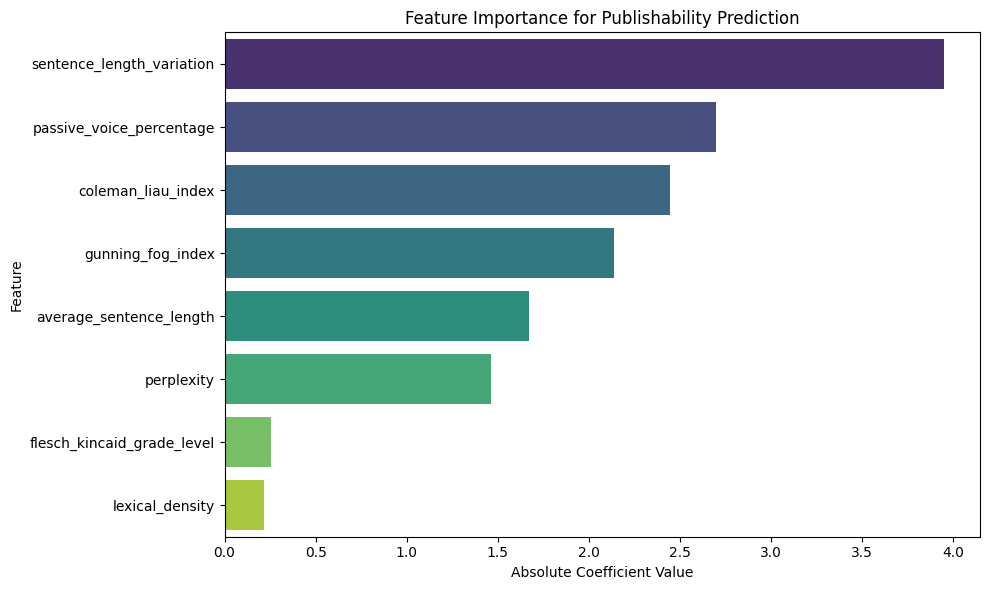

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use absolute value of coefficients as importance score
feature_importance = pd.DataFrame({
    'Feature': input_cols,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance for Publishability Prediction')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

# 💾 STEP 10 — Save Model & Scaler
Save the trained model and scaler as pickle files so they can be loaded later without retraining.

In [ ]:
# Save the trained Logistic Regression model
with open('trained_model_v2.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved to trained_model_v2.pkl")

# Save the MinMaxScaler
with open('scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to scaler_v2.pkl")

Model saved to trained_model_v2.pkl
Scaler saved to scaler_v2.pkl


# 🔮 STEP 11 — Predict on New / Test Papers
Load the saved model and scaler, then run predictions on any new PDFs you want to analyse.

In [ ]:
# Load saved model and scaler
with open('trained_model_v2.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler_v2.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Load test dataset — already has features extracted
test_df = pd.read_csv('test_dataset.csv')
print(f"Test papers loaded: {len(test_df)}")
print(test_df.head())

# Feature columns
input_cols = [
    'gunning_fog_index', 'passive_voice_percentage', 'average_sentence_length',
    'flesch_kincaid_grade_level', 'sentence_length_variation',
    'coleman_liau_index', 'lexical_density', 'perplexity'
]

# Drop rows with missing values
test_df = test_df.dropna(subset=input_cols).reset_index(drop=True)

# Scale using saved scaler — do NOT refit
test_features_scaled = pd.DataFrame(
    loaded_scaler.transform(test_df[input_cols]),
    columns=input_cols
)

# Make predictions
predictions = loaded_model.predict(test_features_scaled)
pred_proba  = loaded_model.predict_proba(test_features_scaled)

test_df['publishable']          = predictions
test_df['prob_publishable']     = pred_proba[:, 1].round(4)
test_df['prob_non_publishable'] = pred_proba[:, 0].round(4)

# Build and save result
result_df = test_df[['paper', 'publishable', 'prob_publishable', 'prob_non_publishable']]
result_df = result_df.sort_values('paper').reset_index(drop=True)
result_df.to_csv('predicted_publishability_v2.csv', index=False)

print(f"\nPublishable:     {sum(predictions == 1)}")
print(f"Non-Publishable: {sum(predictions == 0)}")
print("\nSample predictions:")
print(result_df.head(10))

Test papers loaded: 135
      paper category  gunning_fog_index  passive_voice_percentage  \
0  P062.pdf     test          20.048091                 17.676768   
1  P126.pdf     test          20.485051                 11.059908   
2  P068.pdf     test          19.995381                 19.310345   
3  P008.pdf     test          19.515031                  8.620690   
4  P064.pdf     test          18.854309                 16.201117   

   average_sentence_length  flesch_kincaid_grade_level  \
0                18.593886                   16.723926   
1                16.018868                   16.073596   
2                19.300613                   15.690960   
3                20.302326                   16.440376   
4                17.921397                   15.050418   

   sentence_length_variation  coleman_liau_index  lexical_density   perplexity  
0                   8.170998           15.421884         0.662768  1505.498015  
1                   8.413131           14.690172  

# 📊 STEP 12 — Visualise Prediction Probabilities
Plot the model's confidence for each paper to identify borderline cases.

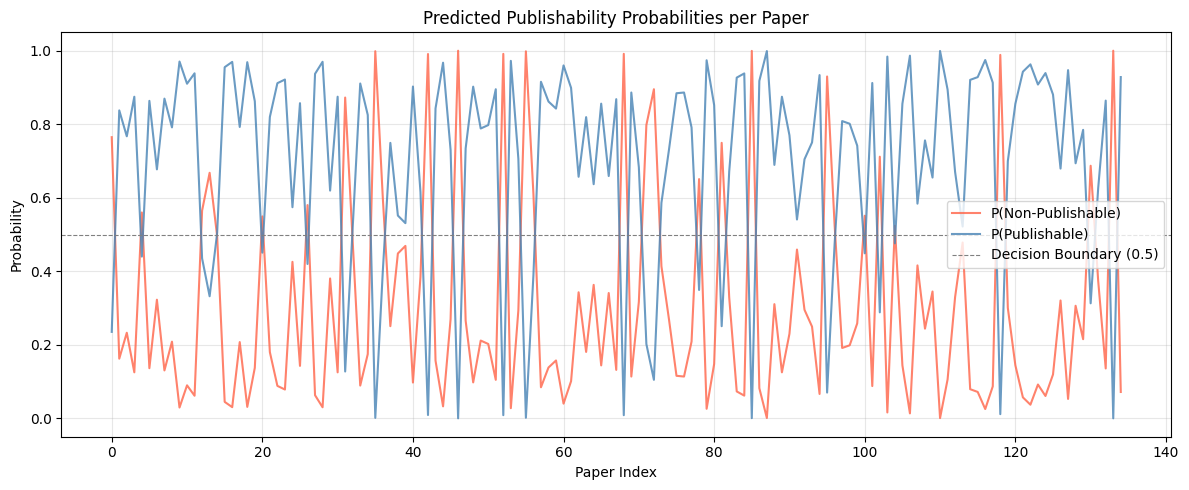

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_df['prob_non_publishable'], label='P(Non-Publishable)', color='tomato',   alpha=0.8)
plt.plot(result_df['prob_publishable'],     label='P(Publishable)',     color='steelblue', alpha=0.8)

plt.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Decision Boundary (0.5)')
plt.xlabel('Paper Index')
plt.ylabel('Probability')
plt.title('Predicted Publishability Probabilities per Paper')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()